
# Adult Income Dataset Analysis

## About The Project
In this project I tried to analyze the Adult Income dataset and understand which factors may affect income.

### What I wanted to do in this project
- Clean the dataset and deal with missing values
- Handle missing values
- Perform Exploratory Data Analysis (EDA)
- Visualize patterns and distributions
- Apply feature encoding and scaling
- Try some machine learning models to predict income
- Evaluate model performance

### Tools & Libraries
- NumPy
- Pandas
- Matplotlib
- Seaborn
- Scikit-learn
- SciPy


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


## Loading the Dataset
The dataset is loaded using Pandas for further analysis and preprocessing.


In [7]:
df = pd.read_csv('adult.csv')


## Handling Missing Values
The dataset contains missing values represented by `?`.  
These values are replaced with `NaN` to make preprocessing easier.


In [8]:
df = df.replace('?', np.nan)

## Dataset Preview

In [9]:
df.head()


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## Dataset Columns

In [10]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country',
       'income'],
      dtype='object')

## Dataset Information

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


## Missing Values Inspection

In [12]:
df.isnull().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,1843
relationship,0
race,0
sex,0



## Renaming Columns
Improving readability of column names.


In [13]:
df.rename(columns={"fnlwgt" : "Final Weight"}, inplace =True )

In [14]:
df.dtypes

,0
age,int64
workclass,object
Final Weight,int64
education,object
education.num,int64
marital.status,object
occupation,object
relationship,object
race,object
sex,object



## Filling Numerical Missing Values
Numerical columns are filled using the mean value.


In [15]:
null_nums = ['age', 'Final Weight', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']
for i in null_nums:
  df[i] = df[i].fillna(df[i].mean())


## Filling Categorical Missing Values
Categorical columns are filled using the mode value.


In [16]:
object_null = ['workclass', 'occupation', 'native.country', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'income']
for i in object_null:
  df[i] = df[i].fillna(df[i].mode()[0])

In [17]:
df.isna().sum()

,0
age,0
workclass,0
Final Weight,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0



# Exploratory Data Analysis (EDA)

These visualizations helped me understand:
- Distribution of features
- Relationships between variables
- Income imbalance
- Demographic patterns


Text(0.5, 1.0, 'Scatter Plot of Age vs. Education Number')

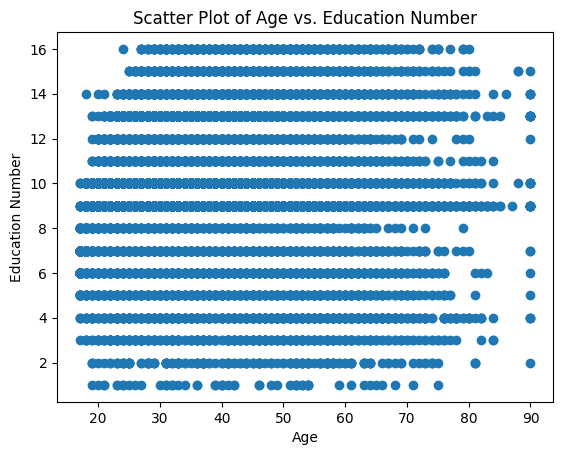

In [18]:
x = df['age']
y = df['education.num']
plt.scatter(x, y)
plt.xlabel('Age')
plt.ylabel('Education Number')
plt.title('Scatter Plot of Age vs. Education Number')

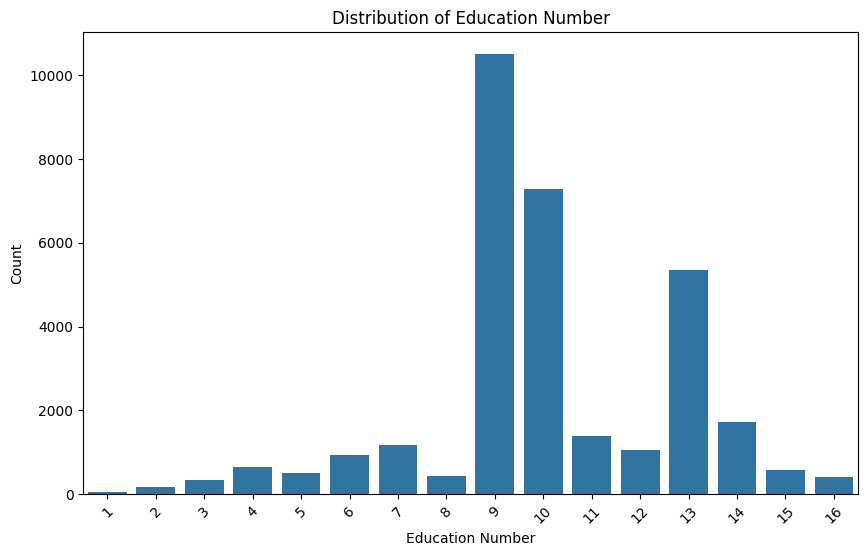

In [19]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='education.num')
plt.xlabel('Education Number')
plt.ylabel('Count')
plt.title('Distribution of Education Number')
plt.xticks(rotation=45)
plt.show()

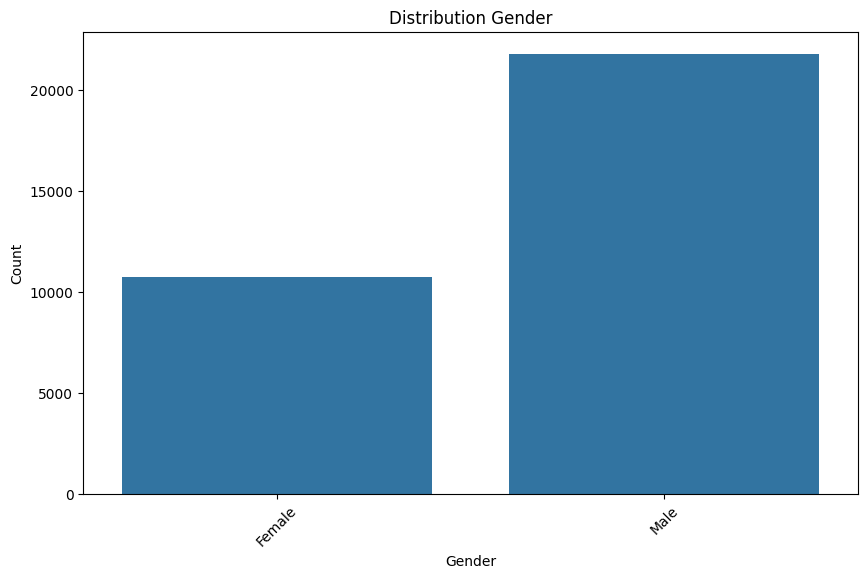

In [20]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='sex')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Distribution Gender')
plt.xticks(rotation=45)
plt.show()

## Correlation Heatmap

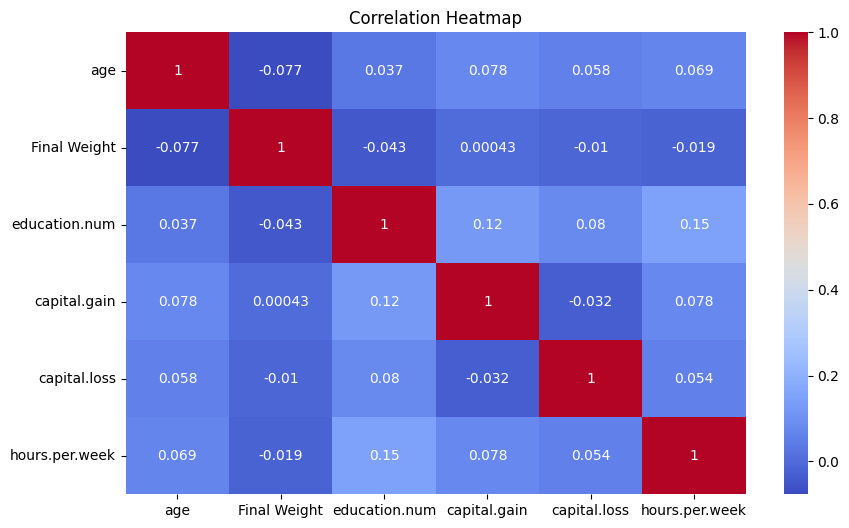

In [21]:

plt.figure(figsize=(10,6))
numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


## Income Distribution

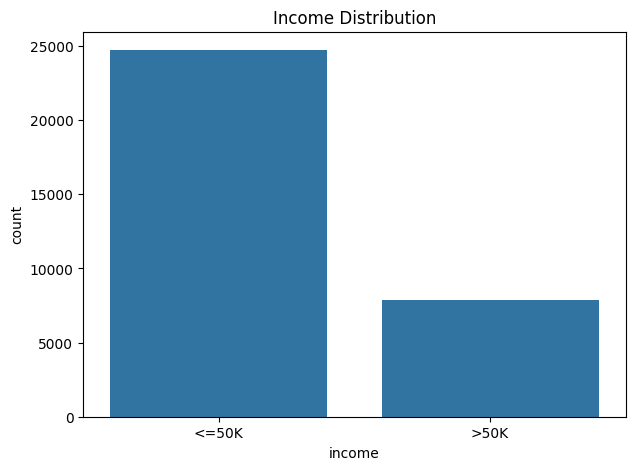

In [22]:

plt.figure(figsize=(7,5))
sns.countplot(data=df, x='income')
plt.title('Income Distribution')
plt.show()


## Age Distribution

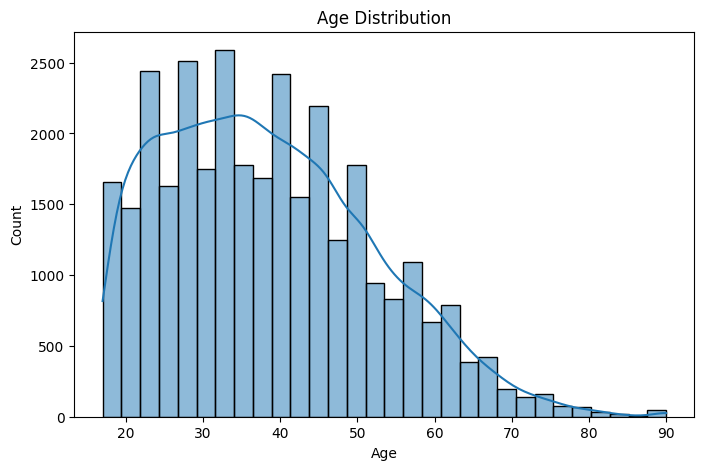

In [23]:

plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.show()



# Statistical Analysis
Basic statistical measures are used to summarize the dataset.


In [24]:
print(np.mean(df['hours.per.week']))
print(np.median(df['age']))
print(df['income'].mode()[0])

40.437455852092995
37.0
<=50K


In [25]:
print(np.std(df['age']))
print(np.var(df['age']))

13.640223092304053
186.05568600782476



## Chi-Square Test
Testing the relationship between Gender and Income.


In [26]:

from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df['sex'], df['income'])

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Statistic:", chi2)
print("P-value:", p)

if p < 0.05:
    print("There is a significant relationship between Gender and Income.")
else:
    print("There is NO significant relationship between Gender and Income.")


Chi-Square Statistic: 1517.813409134445
P-value: 0.0
There is a significant relationship between Gender and Income.



## ANOVA Test
Comparing age and working hours distributions.


In [27]:
from scipy.stats import f_oneway
f_stat, p_value = f_oneway(df['age'], df['hours.per.week'])
print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 331.26800585093514
P-value: 7.763597539660069e-74



# Feature Encoding
Converting categorical values into numerical format using Label Encoding.


In [28]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
objects = ['sex','income','native.country','race','relationship','occupation','marital.status','education','workclass']
for col in objects:
    df[col] = label_encoder.fit_transform(df[col])


# Feature Scaling
Applying Min-Max Scaling to normalize numerical features.


In [29]:
from sklearn.preprocessing import MinMaxScaler
numeric_cols = ['age', 'Final Weight', 'education.num', 'capital.gain','capital.loss','hours.per.week']
scaler = MinMaxScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])


# Machine Learning Models

We will build classification models to predict whether income exceeds 50K.


In [30]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = df.drop('income', axis=1)
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Logistic Regression

In [31]:

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, log_pred))
print(classification_report(y_test, log_pred))


Accuracy: 0.8238906801781053
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4976
           1       0.70      0.44      0.54      1537

    accuracy                           0.82      6513
   macro avg       0.77      0.69      0.72      6513
weighted avg       0.81      0.82      0.81      6513



## Decision Tree Classifier

In [32]:

tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, tree_pred))
print(classification_report(y_test, tree_pred))


Accuracy: 0.8082296944572394
              precision    recall  f1-score   support

           0       0.88      0.87      0.87      4976
           1       0.59      0.61      0.60      1537

    accuracy                           0.81      6513
   macro avg       0.73      0.74      0.74      6513
weighted avg       0.81      0.81      0.81      6513



## Random Forest Classifier

In [33]:

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))


Accuracy: 0.855366190695532
              precision    recall  f1-score   support

           0       0.89      0.93      0.91      4976
           1       0.73      0.61      0.67      1537

    accuracy                           0.86      6513
   macro avg       0.81      0.77      0.79      6513
weighted avg       0.85      0.86      0.85      6513



## Confusion Matrix

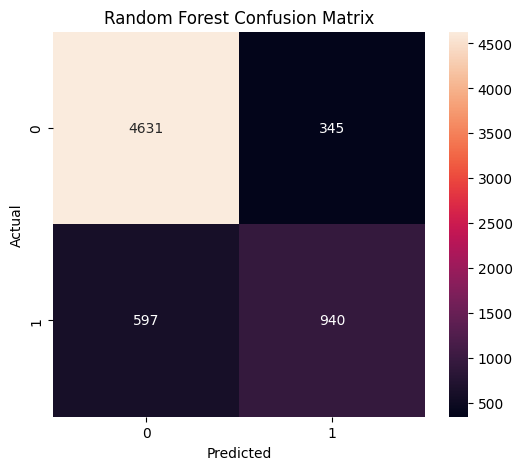

In [34]:

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()



# Final Conclusion

## Key Insights
- Income levels are affected by several demographic and work-related features.
- Education and working hours show noticeable influence on income.
- The dataset required preprocessing due to missing values and categorical variables.
- Random Forest gave the best results compared to the other models.

## Things I may improve later
- Try better feature engineering
- Use advanced hyperparameter tuning
- Try additional ML models
- Deploy the model as a web application



## Personal Notes

While working on this project, I learned more about:
- Handling missing values
- Working with categorical data
- Visualizing data using Seaborn and Matplotlib
- Comparing different machine learning models

Some parts can still be improved, but this project helped me practice the full data analysis workflow from preprocessing to modeling.
